In [1]:
import scipy.io as sio
import numpy as np

DATA_PATH = "/kaggle/input/datasets/sunnyydv602/eeg-dataset/dataset.mat"

mat = sio.loadmat(DATA_PATH)

# Confirm the three variables actually present
for k, v in mat.items():
    if not k.startswith('__'):
        print(k, getattr(v, 'shape', type(v)))

EEGsample (2022, 30, 384)
subindex (2022, 1)
substate (2022, 1)


In [2]:
EEGsample = mat['EEGsample']          # expect (2022, channels, 384)
substate  = mat['substate'].flatten() # 0 = alert, 1 = drowsy
subindex  = mat['subindex'].flatten() # subject id, 1–11

print("EEGsample:", EEGsample.shape)   # resolve the 20-vs-30-channel question here
print("substate:", substate.shape, "unique:", np.unique(substate))
print("subindex:", subindex.shape, "unique subjects:", np.unique(subindex))

EEGsample: (2022, 30, 384)
substate: (2022,) unique: [0 1]
subindex: (2022,) unique subjects: [ 1  2  3  4  5  6  7  8  9 10 11]


In [3]:
import pandas as pd

df = pd.DataFrame({'subject': subindex, 'label': substate})
print("Overall class balance:\n", df['label'].value_counts())
print("\nPer-subject breakdown:\n", df.groupby('subject')['label'].value_counts().unstack(fill_value=0))

Overall class balance:
 label
0    1011
1    1011
Name: count, dtype: int64

Per-subject breakdown:
 label      0    1
subject          
1         94   94
2         66   66
3         75   75
4         74   74
5        112  112
6         83   83
7         51   51
8        132  132
9        157  157
10        54   54
11       113  113


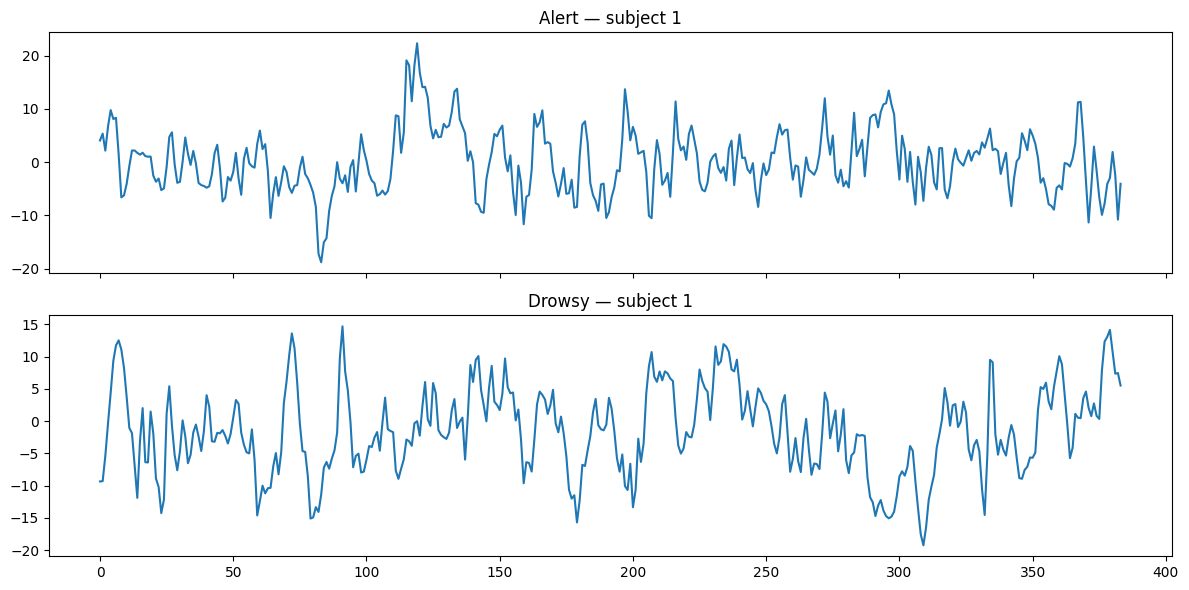

In [4]:
import matplotlib.pyplot as plt

alert_idx  = np.where(substate == 0)[0][0]
drowsy_idx = np.where(substate == 1)[0][0]

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(EEGsample[alert_idx, 0, :])
axes[0].set_title(f"Alert — subject {subindex[alert_idx]}")
axes[1].plot(EEGsample[drowsy_idx, 0, :])
axes[1].set_title(f"Drowsy — subject {subindex[drowsy_idx]}")
plt.tight_layout()
plt.show()


In [5]:
import torch
import torch.nn as nn

class InterpretableCNN(nn.Module):
    """
    Cui et al., "EEG-based Cross-Subject Driver Drowsiness Recognition
    with an Interpretable CNN" (TNNLS, 2022) — built directly from
    Section III.B.3 and Fig. 1.
    """
    def __init__(self, channels=30, n1=16, kernel_length=64, sample_length=384, classes=2):
        super().__init__()
        self.pointwise = nn.Conv2d(1, n1, (channels, 1))                     # spatial filter, 30 -> 16
        self.depthwise = nn.Conv2d(n1, n1 * 2, (1, kernel_length), groups=n1)  # 16 -> 32, temporal
        self.relu = nn.ReLU()
        self.bn = nn.BatchNorm2d(n1 * 2, track_running_stats=False, momentum=0)
        self.gap = nn.AvgPool2d((1, sample_length - kernel_length + 1))
        self.fc = nn.Linear(n1 * 2, classes)

    def forward(self, x):
        x = self.pointwise(x)      # (B, 16, 1, 384)
        x = self.depthwise(x)      # (B, 32, 1, 321)
        x = self.relu(x)
        x = self.bn(x)
        x = self.gap(x)            # (B, 32, 1, 1)
        x = x.view(x.size(0), -1)  # (B, 32)
        return self.fc(x)          # raw logits — pair with CrossEntropyLoss

In [6]:
import torch.optim as optim
from sklearn.metrics import accuracy_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
torch.manual_seed(0)

batch_size = 50
n_epoch = 11  # balanced-dataset peak accuracy (78.35%) occurs here per Fig. 2a

xdata = EEGsample.astype(np.float32)   # (2022, 30, 384) — all channels
ydata = substate.astype(np.int64)
subj  = subindex.astype(np.int64)

results = np.zeros(11)

for i in range(1, 12):
    train_idx = np.where(subj != i)[0]
    test_idx  = np.where(subj == i)[0]

    x_train = xdata[train_idx].reshape(-1, 1, 30, 384)
    y_train = ydata[train_idx]
    x_test  = xdata[test_idx].reshape(-1, 1, 30, 384)
    y_test  = ydata[test_idx]

    train_ds = torch.utils.data.TensorDataset(
        torch.from_numpy(x_train), torch.from_numpy(y_train))
    train_loader = torch.utils.data.DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    net = InterpretableCNN().to(device)
    optimizer = optim.Adam(net.parameters())  # Adam defaults: lr=0.001, betas=(0.9, 0.999)
    loss_fn = nn.CrossEntropyLoss()

    net.train()
    for epoch in range(n_epoch):
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = loss_fn(net(xb), yb)
            loss.backward()
            optimizer.step()

    net.eval()
    with torch.no_grad():
        xt = torch.from_numpy(x_test).to(device)
        preds = net(xt).cpu().numpy().argmax(axis=1)
    acc = accuracy_score(y_test, preds)
    results[i - 1] = acc
    print(f"Subject {i:2d} held out — accuracy: {acc:.4f}")

print(f"\nMean LOSO accuracy: {results.mean():.4f}  (paper reports 78.35%)")

Using device: cuda
Subject  1 held out — accuracy: 0.8564
Subject  2 held out — accuracy: 0.6970
Subject  3 held out — accuracy: 0.7867
Subject  4 held out — accuracy: 0.7838
Subject  5 held out — accuracy: 0.8795
Subject  6 held out — accuracy: 0.8434
Subject  7 held out — accuracy: 0.6667
Subject  8 held out — accuracy: 0.7879
Subject  9 held out — accuracy: 0.8885
Subject 10 held out — accuracy: 0.7315
Subject 11 held out — accuracy: 0.6593

Mean LOSO accuracy: 0.7800  (paper reports 78.35%)


In [7]:
import numpy as np
import torch
import torch.optim as optim
import torch.nn as nn

# 1. Define the held-out subject for our live demo
DEMO_SUBJECT = 1
print(f"Preparing production model. Holding out Subject {DEMO_SUBJECT} for live simulation...")

train_idx = np.where(subj != DEMO_SUBJECT)[0]
demo_idx  = np.where(subj == DEMO_SUBJECT)[0]

x_train = xdata[train_idx].reshape(-1, 1, 30, 384)
y_train = ydata[train_idx]

# Extract and save Subject 1's data for the backend simulator
x_demo = xdata[demo_idx].reshape(-1, 1, 30, 384) # Keep shape explicit for inference
y_demo = ydata[demo_idx]

np.save('demo_subject_x.npy', x_demo)
np.save('demo_subject_y.npy', y_demo)
print(f"Saved demo subject data: {x_demo.shape}")

# 2. Train the final production model
train_ds = torch.utils.data.TensorDataset(torch.from_numpy(x_train), torch.from_numpy(y_train))
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=50, shuffle=True)

production_net = InterpretableCNN().to(device)
optimizer = optim.Adam(production_net.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

production_net.train()
for epoch in range(11): # Train for the optimal 11 epochs
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = loss_fn(production_net(xb), yb)
        loss.backward()
        optimizer.step()

# 3. Export the weights
model_path = 'interpretable_cnn_weights.pt'
torch.save(production_net.state_dict(), model_path)
print(f"Saved production model weights to {model_path}")

Preparing production model. Holding out Subject 1 for live simulation...
Saved demo subject data: (188, 1, 30, 384)
Saved production model weights to interpretable_cnn_weights.pt
